# 06 — Temporal Forecasting with Prophet

**Goal:** Forecast hourly tweet volume and sentiment trends using Facebook Prophet.

**Why this is valid:** The dataset has 181 hourly time points with real timestamps (Feb 17–24, 2015). We model tweet volume as a time series with sentiment as an external regressor.

**What this answers:** 'If sentiment turns more negative tomorrow, how will tweet volume change?'

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

df = pd.read_csv('../data/Tweets.csv')
df['tweet_created'] = pd.to_datetime(df['tweet_created'], utc=True)
df['sentiment_score'] = df['airline_sentiment'].map(
    {'negative': -1, 'neutral': 0, 'positive': 1})

print("Dataset loaded:", df.shape)
print("Date range:", df['tweet_created'].min().date(), "to", df['tweet_created'].max().date())

Dataset loaded: (14640, 16)
Date range: 2015-02-17 to 2015-02-24


## 6.1 Build Hourly Time Series

Hourly time points: 181
                   ds  y  sentiment
0 2015-02-17 07:00:00  4  -0.750000
1 2015-02-17 08:00:00  3  -1.000000
2 2015-02-17 09:00:00  4  -1.000000
3 2015-02-17 10:00:00  3  -0.666667
4 2015-02-17 11:00:00  1   0.000000


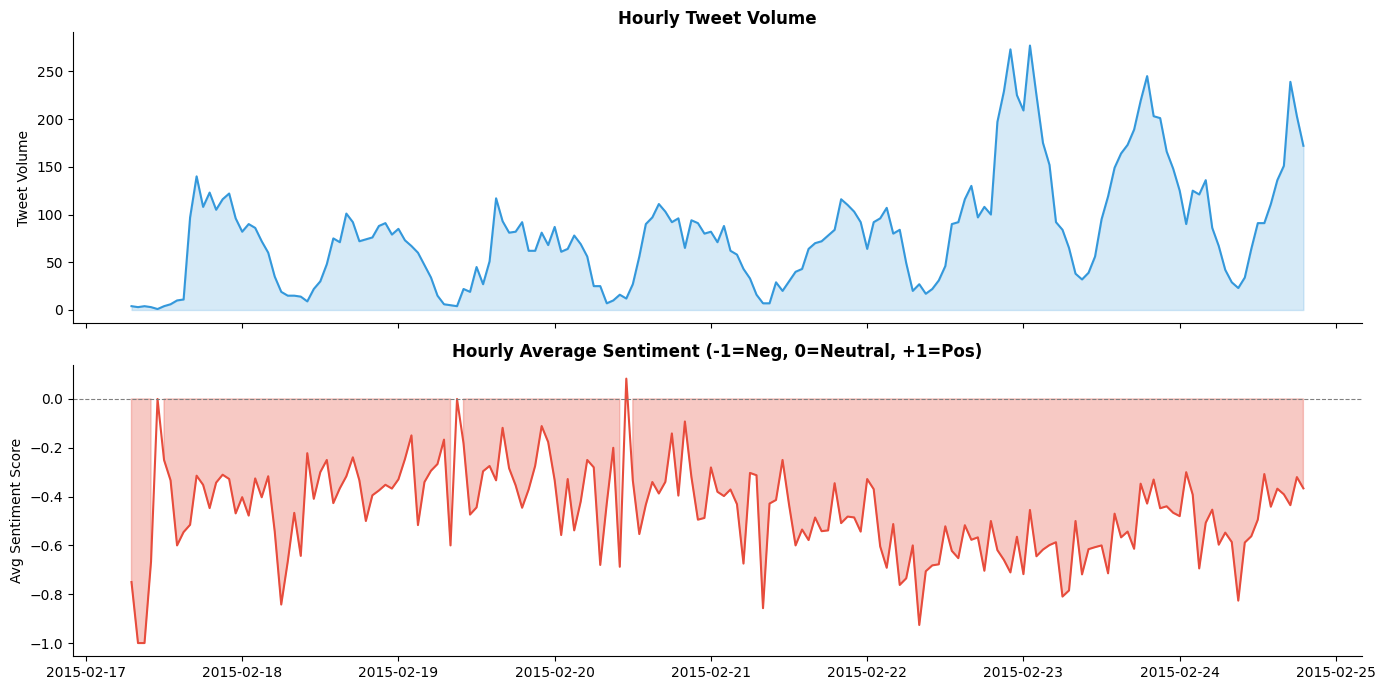

In [2]:
# Aggregate to hourly: tweet volume + average sentiment
hourly = df.groupby(df['tweet_created'].dt.floor('h')).agg(
    tweet_volume=('text', 'count'),
    avg_sentiment=('sentiment_score', 'mean')
).reset_index()
hourly.columns = ['ds', 'y', 'sentiment']
hourly['ds'] = hourly['ds'].dt.tz_localize(None)  # Prophet requires tz-naive

print("Hourly time points:", len(hourly))
print(hourly.head())

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(hourly['ds'], hourly['y'], color='#3498db', linewidth=1.5)
axes[0].fill_between(hourly['ds'], hourly['y'], alpha=0.2, color='#3498db')
axes[0].set_ylabel('Tweet Volume')
axes[0].set_title('Hourly Tweet Volume', fontweight='bold')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].plot(hourly['ds'], hourly['sentiment'], color='#e74c3c', linewidth=1.5)
axes[1].axhline(0, color='grey', linestyle='--', linewidth=0.8)
axes[1].fill_between(hourly['ds'], hourly['sentiment'], 0,
                      where=hourly['sentiment'] < 0, color='#e74c3c', alpha=0.3)
axes[1].fill_between(hourly['ds'], hourly['sentiment'], 0,
                      where=hourly['sentiment'] >= 0, color='#2ecc71', alpha=0.3)
axes[1].set_ylabel('Avg Sentiment Score')
axes[1].set_title('Hourly Average Sentiment (-1=Neg, 0=Neutral, +1=Pos)', fontweight='bold')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../results/06_time_series.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.2 Train Prophet Model

We use Prophet with:
- Daily seasonality (tweet patterns vary by hour of day)
- Sentiment as an external regressor (how does prevailing sentiment shift volume?)

In [3]:
model = Prophet(
    seasonality_mode='additive',
    daily_seasonality=True,
    weekly_seasonality=False,  # only 8 days of data
    yearly_seasonality=False
)
model.add_regressor('sentiment')
model.fit(hourly)
print("Prophet model fitted on", len(hourly), "hourly points.")

20:38:02 - cmdstanpy - INFO - Chain [1] start processing
20:38:04 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted on 181 hourly points.


## 6.3 In-Sample Fit Check

In-sample MAE : 21.72 tweets/hour
In-sample RMSE: 30.05 tweets/hour


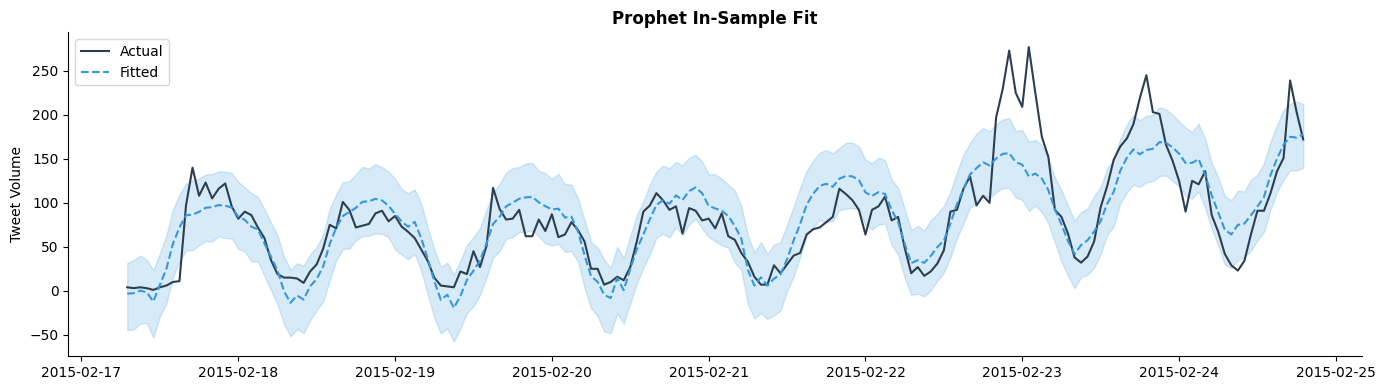

In [4]:
in_sample = model.predict(hourly)

mae = float(mean_absolute_error(hourly['y'], in_sample['yhat']))
rmse = float(np.sqrt(mean_squared_error(hourly['y'], in_sample['yhat'])))
print(f"In-sample MAE : {mae:.2f} tweets/hour")
print(f"In-sample RMSE: {rmse:.2f} tweets/hour")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(hourly['ds'], hourly['y'], label='Actual', color='#2c3e50', linewidth=1.5)
ax.plot(in_sample['ds'], in_sample['yhat'], label='Fitted', color='#3498db',
        linewidth=1.5, linestyle='--')
ax.fill_between(in_sample['ds'], in_sample['yhat_lower'], in_sample['yhat_upper'],
                alpha=0.2, color='#3498db')
ax.set_title('Prophet In-Sample Fit', fontweight='bold')
ax.set_ylabel('Tweet Volume')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../results/06_insample_fit.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.4 Forecast 48 Hours Ahead Under Different Sentiment Scenarios

Negative Sentiment (crisis day): avg forecast = 170.0 tweets/hour
Neutral Sentiment (normal day): avg forecast = 146.1 tweets/hour
Positive Sentiment (good day): avg forecast = 128.2 tweets/hour


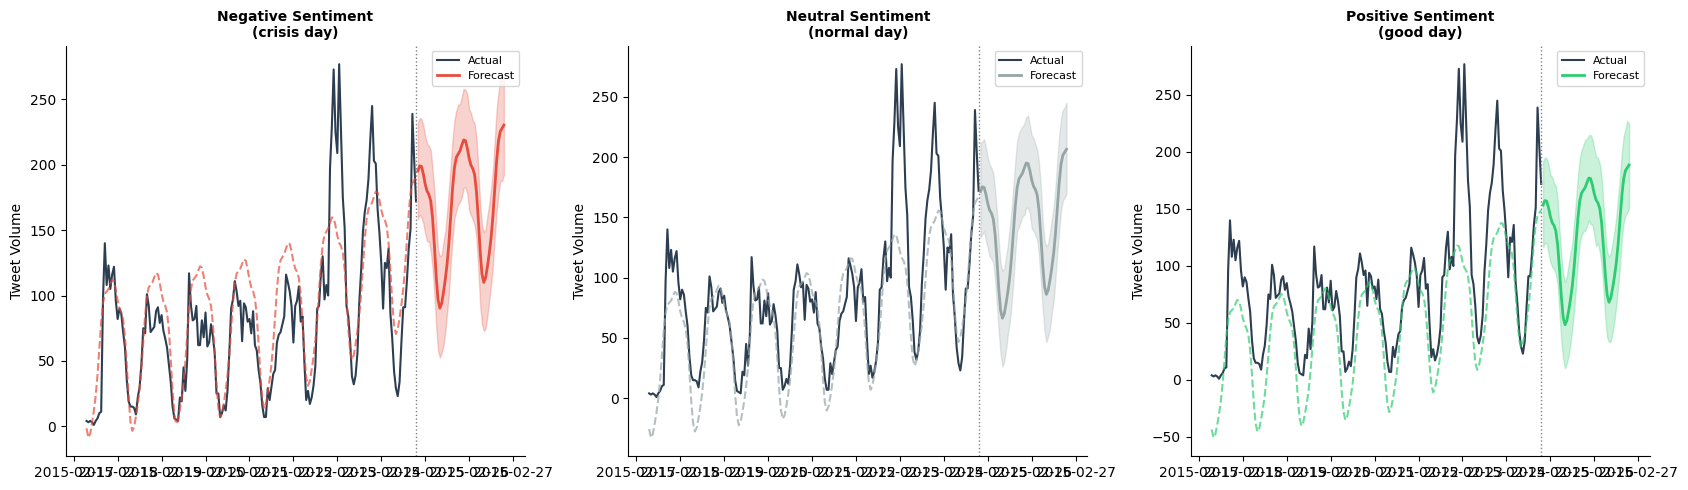

In [5]:
scenarios = {
    'Negative Sentiment\n(crisis day)': -0.8,
    'Neutral Sentiment\n(normal day)':   0.0,
    'Positive Sentiment\n(good day)':    0.6,
}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
colors = ['#e74c3c', '#95a5a6', '#2ecc71']

for ax, (scenario_name, sentiment_val), color in zip(axes, scenarios.items(), colors):
    future = model.make_future_dataframe(periods=48, freq='h')
    future['sentiment'] = sentiment_val
    forecast = model.predict(future)

    # Split historical vs future
    hist_end = hourly['ds'].max()
    future_fc = forecast[forecast['ds'] > hist_end]
    hist_fc   = forecast[forecast['ds'] <= hist_end]

    ax.plot(hourly['ds'], hourly['y'], color='#2c3e50', linewidth=1.5, label='Actual')
    ax.plot(hist_fc['ds'], hist_fc['yhat'], color=color, linewidth=1.5,
            linestyle='--', alpha=0.7)
    ax.plot(future_fc['ds'], future_fc['yhat'], color=color, linewidth=2, label='Forecast')
    ax.fill_between(future_fc['ds'], future_fc['yhat_lower'], future_fc['yhat_upper'],
                    alpha=0.25, color=color)
    ax.axvline(hist_end, color='grey', linestyle=':', linewidth=1)
    ax.set_title(scenario_name, fontweight='bold', fontsize=10)
    ax.set_ylabel('Tweet Volume')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    avg_forecast = float(future_fc['yhat'].mean())
    print(f"{scenario_name.replace(chr(10),' ')}: avg forecast = {avg_forecast:.1f} tweets/hour")

plt.tight_layout()
plt.savefig('../results/06_forecast_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.5 Decomposition — Trend + Daily Seasonality

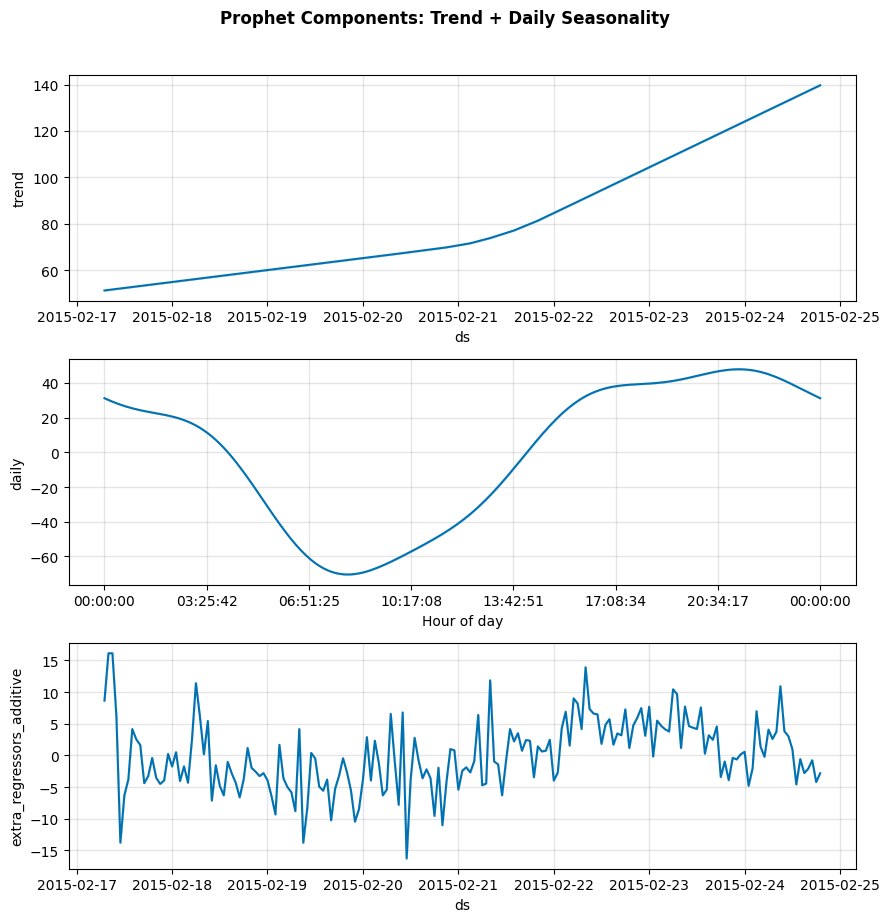

Observation: Peak tweet activity tends to occur in afternoon/evening hours.


In [6]:
fig = model.plot_components(in_sample)
plt.suptitle('Prophet Components: Trend + Daily Seasonality', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/06_prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()
print("Observation: Peak tweet activity tends to occur in afternoon/evening hours.")